---
# DNN : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.datasets import mnist

2025-10-02 11:44:06.845884: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---
## 1. Données
---

### 1.1. Importation

In [2]:
valid_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

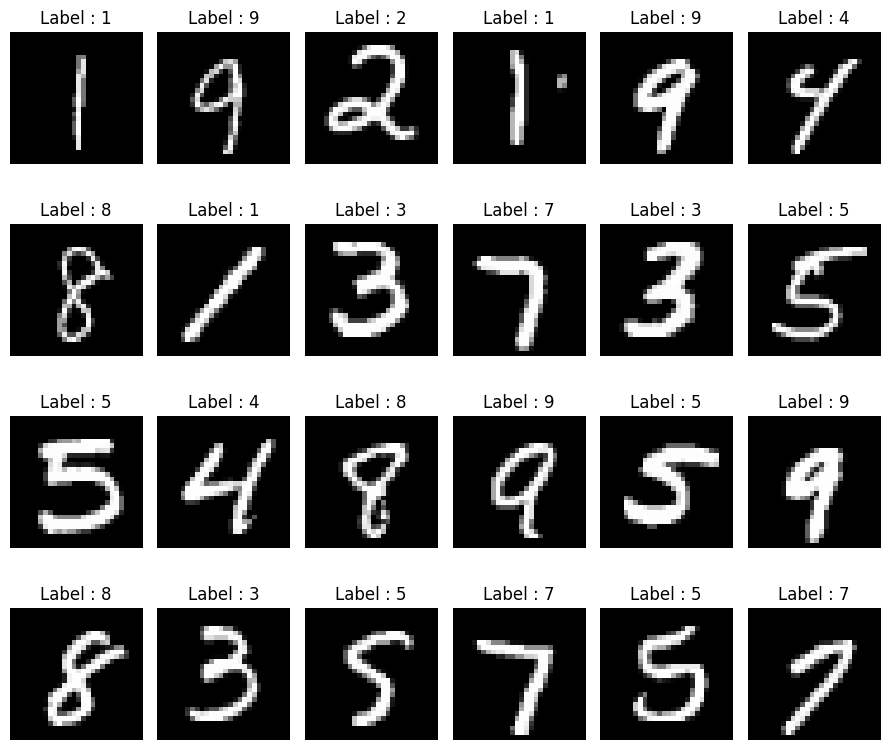

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. DNN
---

### 2.1. Architecture

In [5]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10

n_units_hl1 = 100
n_units_hl2 = 100

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Flatten(name='Flatten'))

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_Layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_Layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_2'))

model.add(layers.Dense(units=dim_outputs, activation='softmax', name='Outputs'))

2025-10-02 11:44:15.406362: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 2.2. Optimiseur

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback=callbacks.EarlyStopping(monitor             = 'val_loss',
                                mode                 = 'min',
                                patience             = 20,
                                restore_best_weights = True)

### 2.3. Entraînement

In [7]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 500,
                 epochs          = 200,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/200


2025-10-02 11:44:16.288860: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7530 - loss: 0.8233 - val_accuracy: 0.9186 - val_loss: 0.2864
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9061 - loss: 0.3229 - val_accuracy: 0.9389 - val_loss: 0.2065
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9282 - loss: 0.2476 - val_accuracy: 0.9505 - val_loss: 0.1654
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9396 - loss: 0.2065 - val_accuracy: 0.9568 - val_loss: 0.1447
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9475 - loss: 0.1789 - val_accuracy: 0.9603 - val_loss: 0.1276
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9535 - loss: 0.1564 - val_accuracy: 0.9647 - val_loss: 0.1174
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9574 - loss: 0.1404 - val_accuracy: 0.9677 - val_loss: 0.1100
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9596 - loss: 0.1316 - val_accuracy: 0.9681 - val_l

### 2.4. Prévisions

In [8]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5.01566113e-08, 9.82163044e-08, 6.57235660e-07, 4.54398287e-06,
        7.39096429e-09, 1.17340754e-07, 5.22963704e-12, 9.99990046e-01,
        9.74848469e-09, 4.42929559e-06],
       [8.05020850e-09, 2.32723346e-06, 9.99982417e-01, 1.49797561e-05,
        3.07229450e-11, 2.43853346e-08, 3.73118897e-10, 7.79083631e-10,
        1.81226540e-07, 2.02954962e-13],
       [7.15800184e-08, 9.99759674e-01, 7.35274443e-05, 2.38038592e-06,
        1.20981931e-05, 2.09374684e-06, 8.77900584e-06, 1.18548000e-04,
        2.25391159e-05, 1.42058497e-07],
       [9.99949515e-01, 1.10034659e-09, 1.28209867e-05, 4.38361241e-07,
        5.96998518e-07, 3.94137032e-06, 1.56799706e-05, 2.90626758e-06,
        5.47676500e-08, 1.40355023e-05],
       [8.62039713e-07, 2.89716979e-07, 7.19020682e-06, 7.66756045e-08,
        9.99277353e-01, 5.08517189e-07, 1.45600438e-06, 1.55476082e-05,
        2.59697146e-07, 6.96501171e-04]], dtype=float32)

In [9]:
y_test_pred_classes = (y_test_pred > 0.5).astype(int)
y_test_pred_classes[0:5]

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

In [10]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0796
Exactitude test : 0.9776


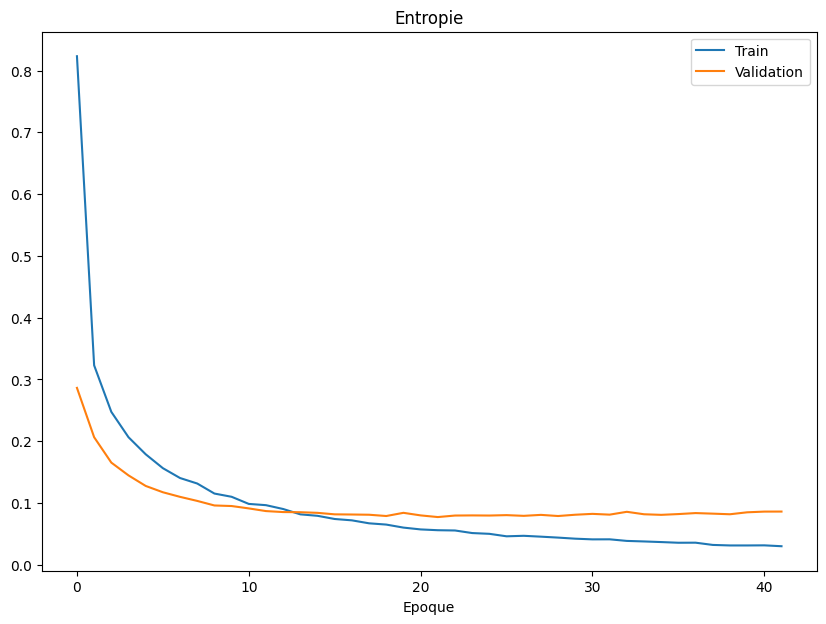

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['loss'], label='Train')
ax.plot(hist.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Entropie')
ax.legend(loc='best')
plt.show()